# **Analyse et Classification des Avis Clients Amazon avec BERT**

## Contexte

Nous travaillons sur le dataset `Industrial_and_Scientific_5.json`, 
contenant 77 071 avis clients Amazon.

Distribution initiale des notes (`overall`) :

- 5.0 → 56 150
- 4.0 → 12 061
- 3.0 → 4 442
- 2.0 → 1 936
- 1.0 → 2 482

## Source 
The dataset is avalaible in Justifying recommendations using distantly-labeled reviews and fined-grained aspects Jianmo Ni, Jiacheng Li, Julian McAuley Empirical Methods in Natural Language Processing (EMNLP), 2019 https://nijianmo.github.io/amazon/index.html#subsets

## Problématique

Le dataset est fortement déséquilibré en faveur des avis positifs.

Nous allons :
- Reformuler le problème en classification 2 classes :
    - Négatif (≤ 2)
    - Positif (≥ 4)
- Équilibrer les classes par sous-échantillonnage.
- Entraîner un modèle BERT via Hugging Face.

## PLAN GLOBAL DU NOTEBOOK

- Chargement des données

- Analyse exploratoire (EDA)

- Gestion du déséquilibre des classes

- Préparation des labels (classification 3 classes)

- Prétraitement texte

- Tokenization avec Hugging Face

- Création Dataset PyTorch

- Fine-tuning BERT

- Évaluation

- Analyse des résultats

## 1️⃣ Import des librairies

Nous importons :
- pandas pour la manipulation des données
- numpy pour le calcul numérique
- matplotlib / seaborn pour la visualisation
- transformers pour BERT
- sklearn pour les métriques
- torch pour le deep learning

In [31]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

import torch
from torch.utils.data import Dataset
from transformers import BertForSequenceClassification, DistilBertForSequenceClassification
from transformers import BertTokenizer
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from pymongo import MongoClient

## 2️⃣ Chargement du dataset

Le fichier est au format JSONL (un JSON par ligne).
contenant au minimum :
- `reviewText` : le texte de l'avis
- `overall` : la note (1 à 5)
- On travaille directement sur les avis bruts.
- On filtrera ensuite pour ne garder que les classes utiles (1–2 et 4–5).


In [12]:
client = MongoClient("mongodb://localhost:27017/")
db = client["amazon_bert_project"]  
reviews = db["reviews"]            

In [13]:
data = []

with open("data/raw/Industrial_and_Scientific_5.json", "r", encoding="utf-8") as content:
    for line in content:
        if line:
            data.append(json.loads(line))

# éviter doublons
if reviews.count_documents({}) == 0:
    reviews.insert_many(data)

print("Total documents :", reviews.count_documents({}))

Total documents : 77071


In [16]:
data = list(reviews.find({}, {"reviewText": 1, "overall": 1}))

df_data = pd.DataFrame(data)

df_data.head()

,_id,overall,reviewText
0,69dd4b2bf01ee8c7b2a640de,5.0,This worked really well for what I used it for...
1,69dd4b2bf01ee8c7b2a640df,5.0,Fast cutting and good adheasive.
2,69dd4b2bf01ee8c7b2a640e0,5.0,Worked great for my lapping bench. I would li...
3,69dd4b2bf01ee8c7b2a640e1,4.0,As advertised
4,69dd4b2bf01ee8c7b2a640e2,5.0,seems like a pretty good value as opposed to b...


## Exploration 

## 3️⃣ Analyse de la distribution des notes

Avant toute transformation, il est essentiel de visualiser 
la distribution des classes.

Cela permet de :
- Justifier le besoin d'équilibrage
- Comprendre la nature du dataset

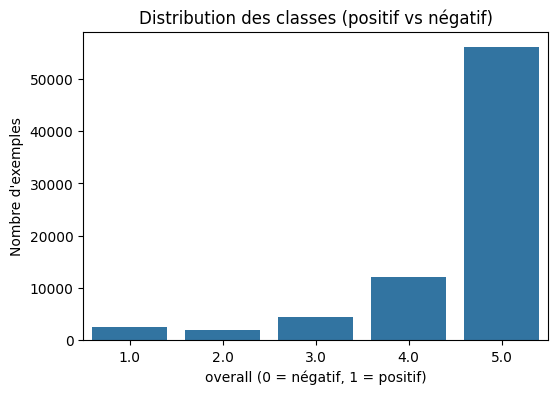

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="overall", data=df_data)
plt.title("Distribution des classes (positif vs négatif)")
plt.xlabel("overall (0 = négatif, 1 = positif)")
plt.ylabel("Nombre d'exemples")
plt.show()

## 4️⃣ Transformation en 2 classes

Nous regroupons les notes :

- Négatif : overall ≤ 2
- Positif : overall ≥ 4

Justification :
Cette transformation permet de formuler le problème 
comme une classification de sentiment standard.

In [18]:
df_neg = df_data[df_data["overall"] <= 2]
df_pos = df_data[df_data["overall"] >= 4]

print("Négatif :", len(df_neg))
print("Positif :", len(df_pos))

Négatif : 4418
Positif : 68211


## 5️⃣ Équilibrage du dataset

Le dataset est déséquilibré.

Nous appliquons un sous-échantillonnage (undersampling) 
afin d'obtenir :

- 4 418 avis négatifs
- 4 418 avis positifs

Total final : 13 254 avis équilibrés.

Justification :
Un dataset équilibré permet :
- D'éviter le biais vers la classe majoritaire
- D'améliorer la robustesse du modèle
- D'obtenir des métriques fiables

In [19]:
df_neg_sample = df_neg.sample(n=4418, random_state=42)
df_pos_sample = df_pos.sample(n=4418, random_state=42)

df_data = pd.concat([df_neg_sample, df_pos_sample],ignore_index=True)

df_data = df_data.sample(frac=1, random_state=42).reset_index(drop=True)

df_data["overall"].value_counts()

overall
5.0    3648
1.0    2482
2.0    1936
4.0     770
Name: count, dtype: int64

## 6️⃣ Encodage des labels

Nous encodons :

- 0 → Négatif
- 2 → Positif

Les modèles Transformers attendent des labels numériques.

In [20]:
def encode_label(x):
    if x <= 2:
        return 0
    else:
        return 1

df_data["label"] = df_data["overall"].apply(encode_label)

df_data[["overall", "label"]].head()

,overall,label
0,1.0,0
1,5.0,1
2,1.0,0
3,2.0,0
4,1.0,0


##  Nettoyage des textes

Le tokenizer BERT nécessite des chaînes de caractères.

Nous allons :
- Supprimer les valeurs nulles
- Convertir explicitement en string

In [21]:
def clean_text(text): 
    if not isinstance(text, str): 
        return "" 
    # Nettoyage minimal 
    text = " ".join(text.split()) 
    return text 
df_data["reviewText"] = df_data["reviewText"].apply(clean_text)

## 7️⃣ Séparation Train / Test

Nous utilisons un split stratifié (80% / 20%) 
afin de conserver l'équilibre des classes.

In [23]:
# 1) Train (80%) + Temp (20%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_data["reviewText"].to_numpy(),
    df_data["label"].to_numpy(),
    test_size=0.2,
    stratify=df_data["label"],
    random_state=42
)

# 2) Temp (20%) → Test (10%) + Validation (10%)
test_texts, val_texts, test_labels, val_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,          # 50% de 20% = 10%
    stratify=temp_labels,
    random_state=42
)


## 8️⃣ Tokenization avec BERT

Nous utilisons le tokenizer pré-entraîné `bert-base-uncased`.

Pourquoi la tokenization est-elle cruciale ?

- BERT ne comprend pas du texte brut.
- Il fonctionne avec des tokens WordPiece.
- Il ajoute automatiquement :
    - [CLS] token
    - [SEP] token
- Il produit :
    - input_ids
    - attention_mask

Nous fixons une longueur maximale (max_length=128)
pour limiter la mémoire GPU.

In [25]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding="max_length",
    max_length=128
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding="max_length",
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding="max_length",
    max_length=128
)


## 9️⃣ Création d'un Dataset PyTorch

Nous créons une classe personnalisée compatible avec Hugging Face Trainer.

Chaque élément du dataset doit retourner :
- input_ids
- attention_mask
- labels

In [36]:
class AmazonReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {}

        for key, val in self.encodings.items():
            item[key] = torch.tensor(val[idx], dtype=torch.long)

        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

    def __len__(self):
        return len(self.labels)


train_dataset = AmazonReviewDataset(train_encodings, train_labels)
val_dataset = AmazonReviewDataset(val_encodings, val_labels)
test_dataset = AmazonReviewDataset(test_encodings, test_labels)

## 🔟 Chargement du modèle BERT

Nous utilisons BertForSequenceClassification.

Nous définissons :
- num_labels = 2 (Négatif/ Positif)

BERT ajoute automatiquement une couche linéaire de classification.

In [32]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 630.16it/s, Materializing param=distilbert.transform

## 1️⃣1️⃣ Définition des métriques d'évaluation

Nous calculons :
- Accuracy
- Precision
- Recall
- F1-score

Le F1-score est particulièrement important en classification multi-classe.

In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 1️⃣2️⃣ Paramètres d'entraînement

Nous définissons :
- learning_rate = 2e-5 (classique pour BERT)
- batch_size = 8
- epochs = 2


In [38]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,   
    per_device_eval_batch_size=8,
    num_train_epochs=2,              
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 1️⃣3️⃣ Initialisation du Trainer

Le Trainer de Hugging Face simplifie :

- Boucle d'entraînement
- Validation
- Sauvegarde
- Gestion GPU

In [39]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset, 
    compute_metrics=compute_metrics,
)

## 1️⃣4️⃣ Entraînement du modèle

In [40]:
trainer.train()

C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.332750,0.253996,0.925339,0.927871,0.925339,0.925229
2,0.159315,0.247869,0.937783,0.937785,0.937783,0.937783


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]
C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.18it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1768, training_loss=0.23107247978314016, metrics={'train_runtime': 5012.2412, 'train_samples_per_second': 2.82, 'train_steps_per_second': 0.353, 'total_flos': 468139786850304.0, 'train_loss': 0.23107247978314016, 'epoch': 2.0})

## 1️⃣5️⃣ Évaluation finale

In [41]:
trainer.evaluate()

C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.24786892533302307,
 'eval_accuracy': 0.9377828054298643,
 'eval_precision': 0.9377850462984292,
 'eval_recall': 0.9377828054298643,
 'eval_f1': 0.9377827258127467,
 'eval_runtime': 62.3021,
 'eval_samples_per_second': 14.189,
 'eval_steps_per_second': 1.782,
 'epoch': 2.0}

## 1️⃣6️⃣ Matrice de confusion

Permet d’analyser les erreurs entre classes.

C:\Users\hp\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


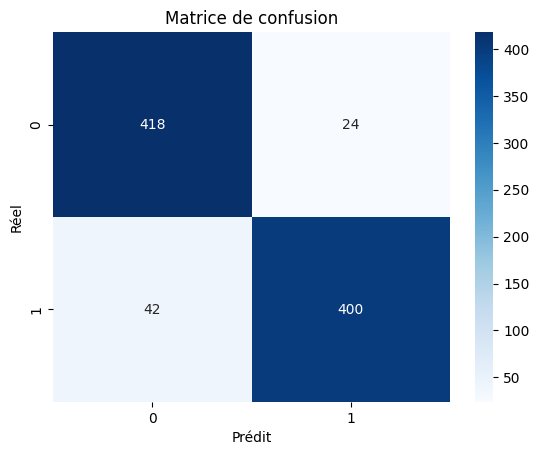

In [42]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

cm = confusion_matrix(test_labels, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion")
plt.show()